# mROSE sequence generation example

This notebook runs compact mROSE generation examples for the three major mRNA regions and a full-length mRNA composition workflow. The checked-in outputs were generated on the project server with the released checkpoints.


<p align="center">
  <img src="../docs/assets/mrose-icon.png" alt="mROSE icon" width="150">
</p>

<p align="center">
  <img src="../docs/assets/mrose-figure1.png" alt="mROSE workflow" width="900">
</p>


## 1. Setup

The notebook assumes it is run from either the repository root or the `notebooks/` directory. Generation logs are captured internally so the visible output stays focused on results.


In [1]:
from pathlib import Path
import os
import subprocess
import sys
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
if (cwd / "mrose").is_dir():
    PROJECT_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "mrose").is_dir():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



## 2. Readiness check

Only essential readiness information is shown. Checkpoint file sizes are intentionally omitted from the notebook output.


In [2]:
import importlib.util

required_modules = ["numpy", "pandas", "torch", "Bio", "sklearn", "scipy", "tqdm"]
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]
vienna_ready = importlib.util.find_spec("ViennaRNA") is not None or importlib.util.find_spec("RNA") is not None

checkpoint_paths = {
    "5' UTR": PROJECT_ROOT / "generation" / "5utr" / "Model.pth",
    "CDS": PROJECT_ROOT / "generation" / "cds" / "Model.pth",
    "3' UTR": PROJECT_ROOT / "generation" / "3utr" / "Model.pth",
}
missing_checkpoints = [name for name, path in checkpoint_paths.items() if not path.exists()]

print("Environment:", "ready" if not missing_modules else "missing " + ", ".join(missing_modules))
print("RNA folding:", "ready" if vienna_ready else "not available")
print("Checkpoints:", "ready" if not missing_checkpoints else "missing " + ", ".join(missing_checkpoints))


Environment: ready
RNA folding: ready
Checkpoints: ready


## 3. Run compact generation examples

The commands below generate candidates for 5′ UTR, CDS and 3′ UTR, then run the
full-length launcher. The full-length workflow takes a **single full-length mRNA
sequence** as input, automatically splits it into 5′ UTR, CDS and 3′ UTR
regions (by locating ATG and the first downstream in-frame stop codon), runs
each regional generator independently, and merges same-rank candidates into
complete mRNA transcripts.

Verbose command-line output is captured internally so the notebook stays focused
on candidate results.


In [3]:
TASKS = {
    "5' UTR": {
        "script": PROJECT_ROOT / "generation" / "5utr" / "generate_5utr.py",
        "checkpoint": PROJECT_ROOT / "generation" / "5utr" / "Model.pth",
        "input_fasta": PROJECT_ROOT / "generation" / "examples" / "5utr_template.fasta",
        "output_dir": PROJECT_ROOT / "outputs" / "generation" / "5utr_example",
        "args": ["--num_samples", "10000", "--top_k", "5", "--device", "cuda:0", "--output_prefix", "example_5utr"],
        "top_csv": PROJECT_ROOT / "outputs" / "generation" / "5utr_example" / "example_5utr_top5.csv",
        "all_csv": PROJECT_ROOT / "outputs" / "generation" / "5utr_example" / "example_5utr_all_scored.csv",
    },
    "CDS": {
        "script": PROJECT_ROOT / "generation" / "cds" / "generate_cds.py",
        "checkpoint": PROJECT_ROOT / "generation" / "cds" / "Model.pth",
        "input_fasta": PROJECT_ROOT / "generation" / "examples" / "cds_template.fasta",
        "output_dir": PROJECT_ROOT / "outputs" / "generation" / "cds_example",
        "args": ["--num_samples", "10000", "--top_k", "5", "--device", "cuda:0", "--mfe_weight", "0"],
        "top_csv": PROJECT_ROOT / "outputs" / "generation" / "cds_example" / "top10_generated_scored.csv",
        "all_csv": PROJECT_ROOT / "outputs" / "generation" / "cds_example" / "all_generated_scored.csv",
    },
    "3' UTR": {
        "script": PROJECT_ROOT / "generation" / "3utr" / "generate_3utr.py",
        "checkpoint": PROJECT_ROOT / "generation" / "3utr" / "Model.pth",
        "input_fasta": PROJECT_ROOT / "generation" / "examples" / "3utr_template.fasta",
        "output_dir": PROJECT_ROOT / "outputs" / "generation" / "3utr_example",
        "args": ["--num_samples", "10000", "--top_k", "5", "--device", "cuda:0", "--match_input_length", "--output_prefix", "example_3utr"],
        "top_csv": PROJECT_ROOT / "outputs" / "generation" / "3utr_example" / "example_3utr_top5.csv",
        "all_csv": PROJECT_ROOT / "outputs" / "generation" / "3utr_example" / "example_3utr_all_scored.csv",
    },
    "Full-length mRNA": {
        "script": PROJECT_ROOT / "generation" / "full_length" / "generate_full_length.py",
        "output_dir": PROJECT_ROOT / "outputs" / "generation" / "full_length_example",
        "args": [
            "--full_mrna_fasta", str(PROJECT_ROOT / "generation" / "examples" / "full_mrna_template.fasta"),
            "--num_samples", "100",
            "--top_k", "5",
            "--device", "cuda:0",
            "--output_prefix", "example_full_length",
        ],
        "top_csv": PROJECT_ROOT / "outputs" / "generation" / "full_length_example" / "example_full_length_top5.csv",
    },
}

run_logs = {}
for region, cfg in TASKS.items():
    cfg["output_dir"].mkdir(parents=True, exist_ok=True)
    command = [sys.executable, str(cfg["script"])]
    if "checkpoint" in cfg:
        command.extend(["--checkpoint", str(cfg["checkpoint"])])
    if "input_fasta" in cfg:
        command.extend(["--input_fasta", str(cfg["input_fasta"])])
    command.extend(["--output_dir", str(cfg["output_dir"]), *cfg["args"]])
    run_env = os.environ.copy()
    run_env.setdefault("MKL_THREADING_LAYER", "GNU")
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        env=run_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )
    run_logs[region] = result.stdout
    if result.returncode != 0:
        print(run_logs[region])
        raise RuntimeError(f"{region} generation failed with exit code {result.returncode}")
    print(f"{region}: generated top candidates -> {cfg['top_csv'].relative_to(PROJECT_ROOT)}")


5' UTR: generated top candidates -> outputs/generation/5utr_example/example_5utr_top5.csv
CDS: generated top candidates -> outputs/generation/cds_example/top10_generated_scored.csv
3' UTR: generated top candidates -> outputs/generation/3utr_example/example_3utr_top5.csv
Full-length mRNA: generated top candidates -> outputs/generation/full_length_example/example_full_length_top5.csv


## 4. Result tables

The tables show the top candidates with only the most useful design metrics. Long sequences are shortened for readability.


In [4]:
def shorten_sequence(sequence, width=42):
    sequence = str(sequence)
    if len(sequence) <= width:
        return sequence
    flank = max(8, (width - 3) // 2)
    return f"{sequence[:flank]}...{sequence[-flank:]}"


def calc_gc(seq):
    seq = str(seq).upper()
    if len(seq) == 0:
        return 0.0
    return (seq.count("G") + seq.count("C")) / len(seq)


def standardize_region_table(region, path):
    df = pd.read_csv(path).head(5).copy()
    df.insert(0, "region", region)
    if "rank" not in df.columns:
        df.insert(1, "rank", np.arange(1, len(df) + 1))
    if region == "5' UTR":
        out = pd.DataFrame({
            "region": df["region"],
            "rank": df["rank"],
            "final_score": df["final_score"],
            "primary_metric": df["mrl_pred"],
            "primary_label": "MRL",
            "gc": df["GC"],
            "mfe": df["mfe"],
            "cai": np.nan,
            "length": df["sequence"].astype(str).str.len(),
            "sequence": df["sequence"],
        })
    elif region == "CDS":
        out = pd.DataFrame({
            "region": df["region"],
            "rank": df["rank"],
            "final_score": df["final_score"],
            "primary_metric": df["pred_value"],
            "primary_label": "pred_value",
            "gc": df["gc"],
            "mfe": df["MFE"],
            "cai": df["CAI"],
            "length": df["length_nt"],
            "sequence": df["sequence"],
        })
    elif region == "3' UTR":
        out = pd.DataFrame({
            "region": df["region"],
            "rank": df["rank"],
            "final_score": df["final_score"],
            "primary_metric": df["pred_value"],
            "primary_label": "degradation_pred",
            "gc": df["GC"],
            "mfe": df["MFE"],
            "cai": np.nan,
            "length": df["length"],
            "sequence": df["sequence"],
        })
    else:  # Full-length mRNA — enriched breakdown
        # Compute per-region GC
        df["five_utr_gc"] = df["five_utr_sequence"].map(calc_gc)
        df["cds_gc"] = df["cds_sequence"].map(calc_gc)
        df["three_utr_gc"] = df["three_utr_sequence"].map(calc_gc)
        out = pd.DataFrame({
            "region": df["region"],
            "rank": df["rank"],
            "full_length": df["full_length"].astype(int),
            "5utr_len": df["five_utr_length"].astype(int),
            "cds_len": df["cds_length"].astype(int),
            "3utr_len": df["three_utr_length"].astype(int),
            "5utr_score": df["five_utr_score"].astype(float).round(4),
            "cds_score": df["cds_score"].astype(float).round(4),
            "3utr_score": df["three_utr_score"].astype(float).round(4),
            "5utr_gc": df["five_utr_gc"].round(3),
            "cds_gc": df["cds_gc"].round(3),
            "3utr_gc": df["three_utr_gc"].round(3),
            "sequence": df["sequence"],
            "five_utr_sequence": df["five_utr_sequence"],
            "cds_sequence": df["cds_sequence"],
            "three_utr_sequence": df["three_utr_sequence"],
        })
    out["sequence_preview"] = out["sequence"].map(shorten_sequence)
    return out

region_tables = [standardize_region_table(region, cfg["top_csv"]) for region, cfg in TASKS.items()]
summary = pd.concat(region_tables, ignore_index=True)
summary_view = summary[["region", "rank", "final_score", "primary_label", "primary_metric", "gc", "mfe", "cai", "length", "sequence_preview"]].copy()
for col in ["final_score", "primary_metric", "gc", "mfe", "cai"]:
    summary_view[col] = summary_view[col].astype(float).round(4)
print(summary_view.to_string(index=False))



          region  rank  final_score    primary_label  primary_metric     gc    mfe    cai  length                          sequence_preview
          5' UTR     1       0.8332              MRL          6.8371 0.5094  -3.47    NaN    53.0 AGGAGAGGAGGGGCAAGCA...CATCAGAAGAAGAGCCACC
          5' UTR     2       0.8271              MRL          6.7238 0.5625  -0.60    NaN    48.0 AGGATCGTGTAGAGTAGCA...AGAGTGAACAGGGGCCACC
          5' UTR     3       0.8267              MRL          6.7048 0.4231   0.00    NaN    52.0 AGGATAGGAAACAAACTAA...GAACATAGGTATAGCCACC
          5' UTR     4       0.8216              MRL          6.7668 0.5686  -3.30    NaN    51.0 AGGAGGGATAAAGCGGACA...TAGCACCACCAGGGCCACC
          5' UTR     5       0.8199              MRL          6.6995 0.5000  -1.20    NaN    52.0 AGGAGGACCATCATCAGGG...CAGAAGAAAGACTGCCACC
             CDS     1       0.8297       pred_value          1.2000 0.5726 -34.00 0.6596   117.0 ATGGCGGAAGAGCTGTTCA...TACCGAGGCGGCCGAATAG
             CDS    

## 5. Full-length mRNA composition

The full-length launcher receives a single mRNA sequence and automatically
splits it into three regions by ORF detection:

- **5′ UTR** = everything before the first ATG
- **CDS** = from ATG through the first in-frame stop codon (TAA/TAG/TGA)
- **3′ UTR** = everything after the stop codon

Each region is then fed to its dedicated mROSE generator, and same-rank outputs
are concatenated to produce complete mRNA candidates:

```
full_length_rank_1 = 5utr_generated_rank_1 + cds_generated_rank_1 + 3utr_generated_rank_1
full_length_rank_2 = 5utr_generated_rank_2 + cds_generated_rank_2 + 3utr_generated_rank_2
  ...
```

The table below shows the regional breakdown for each full-length candidate,
including per-region scores, lengths and GC content.

In [5]:
# Extract full-length results from the merged summary
fl_df = summary[summary["region"] == "Full-length mRNA"].copy()

# Composition breakdown table
composition_cols = [
    "rank", "full_length",
    "5utr_len", "5utr_score", "5utr_gc",
    "cds_len", "cds_score", "cds_gc",
    "3utr_len", "3utr_score", "3utr_gc",
    "sequence_preview"
]
comp_view = fl_df[composition_cols].copy()
print("Full-length mRNA composition — regional breakdown")
print("=" * 90)
print(comp_view.to_string(index=False))

# Per-region sequence details for the top candidate
print("\n\nTop candidate (rank 1) — regional sequences:")
print("-" * 50)
top = fl_df[fl_df["rank"] == 1].iloc[0]
print(f"5′ UTR ({int(top['5utr_len'])} nt, score={top['5utr_score']}): {top['five_utr_sequence']}")
print(f"CDS   ({int(top['cds_len'])} nt, score={top['cds_score']}): {top['cds_sequence']}")
print(f"3′ UTR ({int(top['3utr_len'])} nt, score={top['3utr_score']}): {top['three_utr_sequence']}")
print(f"\nFull  ({int(top['full_length'])} nt):\n{top['sequence']}")


Full-length mRNA composition — regional breakdown
 rank  full_length  5utr_len  5utr_score  5utr_gc  cds_len  cds_score  cds_gc  3utr_len  3utr_score  3utr_gc                          sequence_preview
    1        263.0      50.0      0.8185    0.540    117.0     0.8217   0.513      96.0      0.7387    0.573 AGGAAAGGATCGCGCGAGG...TCAGCCGGTGACGGGGCTG
    2        262.0      49.0      0.8097    0.571    117.0     0.7831   0.547      96.0      0.7162    0.625 AGGAAAAGGCCTACGCAGC...AGGTGCACCTGAAATGACC
    3        264.0      51.0      0.7725    0.490    117.0     0.7827   0.547      96.0      0.6934    0.510 AGGTAGAGATATCATCGGG...ACCAAAAACCATGAATAAA
    4        262.0      49.0      0.7658    0.490    117.0     0.7597   0.581      96.0      0.6864    0.521 AGGACATACCTATAAAATA...GCCCATACTCAAACAGAAA
    5        268.0      55.0      0.7600    0.527    117.0     0.7538   0.581      96.0      0.6839    0.552 AGGAATACCACATCAAAGC...AAGCGGTATCGAGGCAGGA


Top candidate (rank 1) — regional sequence

### Composition diagram

The stacked bar chart below visualises how each full-length candidate is built from
its three regional components, colored by region.


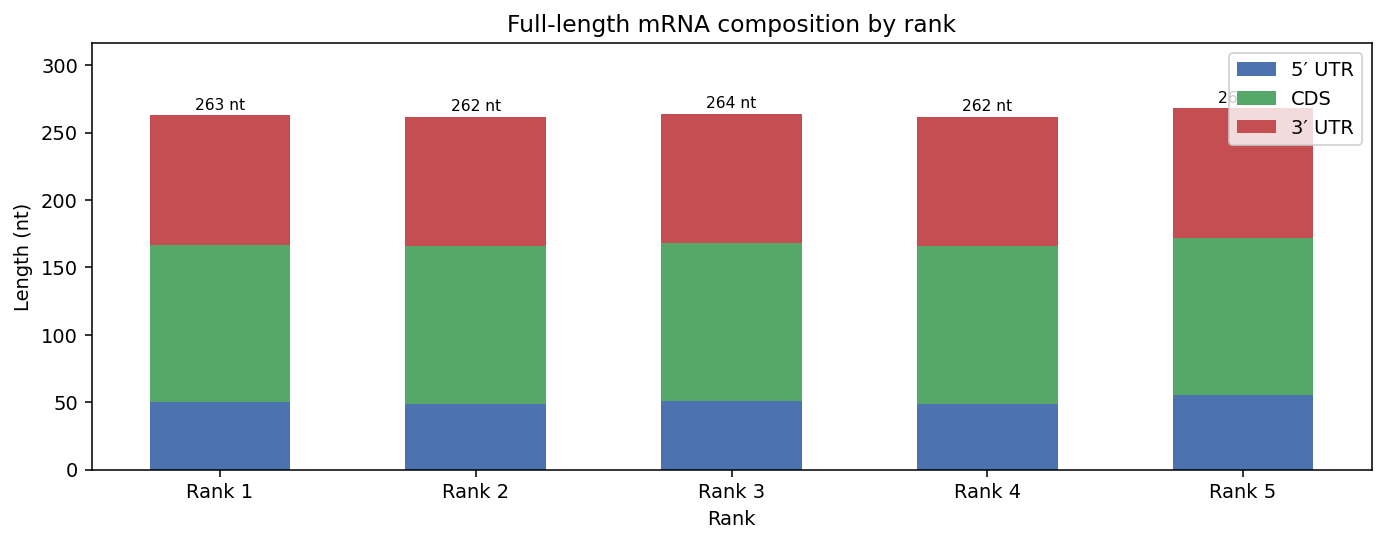

In [6]:
# Stacked bar chart: regional length contributions per rank
fig, ax = plt.subplots(figsize=(10, 4))

ranks = fl_df["rank"].values
x = np.arange(len(ranks))
width = 0.55

bars_5 = ax.bar(x, fl_df["5utr_len"], width, label="5′ UTR", color="#4c72b0")
bars_c = ax.bar(x, fl_df["cds_len"], width, bottom=fl_df["5utr_len"], label="CDS", color="#55a868")
bars_3 = ax.bar(x, fl_df["3utr_len"], width, bottom=fl_df["5utr_len"] + fl_df["cds_len"], label="3′ UTR", color="#c44e52")

# Annotate total length on top of each bar
for i, (r, total) in enumerate(zip(ranks, fl_df["full_length"])):
    ax.text(i, total + 2, f"{int(total)} nt", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Rank")
ax.set_ylabel("Length (nt)")
ax.set_title("Full-length mRNA composition by rank")
ax.set_xticks(x)
ax.set_xticklabels([f"Rank {r}" for r in ranks])
ax.legend(loc="upper right", frameon=True)
ax.set_ylim(0, fl_df["full_length"].max() * 1.18)

plt.tight_layout()
plt.show()


## 6. Summary

The notebook demonstrates end-to-end mROSE generation across all four task types:

- **5′ UTR**, **CDS** and **3′ UTR** region-specific candidates with scoring metrics.
- **Full-length mRNA** candidates assembled by rank-wise regional concatenation,
  with per-region score and length breakdown.

Generated FASTA and CSV files are saved under `outputs/generation/`.
